In [ ]:
import numpy as np


# 1. DEFINICIÓN DE LAS MATRICES DE ADYACENCIA
# Convención: A[i][j] = 1 significa que hay un enlace del nodo 'i' al nodo 'j'


# RED PROPUESTA (6 Nodos)
# Tiene un ciclo (0->1->2->0) y un nodo sumidero (5 no tiene salidas)
A_propuesta = np.array([
    [0, 1, 0, 0, 0, 0], # Nodo 0 apunta a 1
    [0, 0, 1, 0, 0, 0], # Nodo 1 apunta a 2
    [1, 0, 0, 1, 0, 0], # Nodo 2 apunta a 0 y 3 (Cierra ciclo 0-1-2)
    [0, 0, 0, 0, 1, 0], # Nodo 3 apunta a 4
    [0, 0, 0, 0, 0, 1], # Nodo 4 apunta a 5
    [0, 0, 0, 0, 0, 0]  # Nodo 5 es sumidero (C_5 = 0)
])

#  GRAFO 1
# Nodos: 0, 1, 2. Enlaces: 0->1, 0->2, 1->2.
# El nodo 2 es un sumidero.
A_grafo_1 = np.array([
    [0, 1, 1],
    [0, 0, 1],
    [0, 0, 0]
])

#  GRAFO 2
# Nodos: 0, 1, 2, 3.
# Es un grafo fuertemente conectado en forma de anillo bidireccional.
# Enlaces: 0<->1, 1<->2, 2<->3, 3<->0.
A_grafo_2 = np.array([
    [0, 1, 0, 1],
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [1, 0, 1, 0]
])

#  GRAFO 3
# Nodos: 0 al 7.
# Son dos subgrafos completamente desconectados (0,1,2,3 y 4,5,6,7).
A_grafo_3 = np.array([
    [0, 1, 1, 0, 0, 0, 0, 0], # Nodo 0
    [1, 0, 1, 0, 0, 0, 0, 0], # Nodo 1
    [1, 1, 0, 1, 0, 0, 0, 0], # Nodo 2
    [0, 0, 1, 0, 0, 0, 0, 0], # Nodo 3
    [0, 0, 0, 0, 0, 1, 1, 0], # Nodo 4
    [0, 0, 0, 0, 1, 0, 1, 0], # Nodo 5
    [0, 0, 0, 0, 1, 1, 0, 1], # Nodo 6
    [0, 0, 0, 0, 0, 0, 1, 0]  # Nodo 7
])

#  GRAFO 4
# Nodos: 0, 1, 2, 3, 4.
# Enlaces: 0->1, 2->0, 1->2, 2->3, y bidireccional entre 3<->4.
A_grafo_4 = np.array([
   [0, 1, 0, 0, 0], # Nodo 0 apunta a 1
    [0, 0, 1, 0, 0], # Nodo 1 apunta a 2
    [1, 0, 0, 1, 0], # Nodo 2 apunta a 0 y 3
    [0, 0, 0, 0, 1], # Nodo 3 apunta a 4
    [0, 0, 0, 1, 0]  # Nodo 4 apunta a 3
])

#  GRAFO 5
# Nodos: 0, 1, 2.
# Enlaces: 2->0, y bidireccional 0<->1.
A_grafo_5 = np.array([
    [0, 1, 0], # Nodo 0 -> 1
    [1, 0, 0], # Nodo 1 -> 0
    [1, 0, 0]  # Nodo 2 -> 0
])



# 2. IMPLEMENTACIÓN DEL ALGORITMO PAGERANK


def calcular_pagerank(A, nombre_grafo, d=0.85, tol=1e-8, max_iter=1000):
    """
    Construye la matriz de Google y aplica el método de las potencias.
    """
    print(f"Analisis {nombre_grafo}")

    A = np.array(A, dtype=float)
    n = A.shape[0]
    print(f"1. Matriz de Adyacencia A ({n}x{n}):\n{A}\n")

    # Calcular el grado de salida (C_j) de cada nodo sumando las filas
    C = np.sum(A, axis=1)

    # Construcción de la Matriz de Transición M
    # M_ij = 1 / C_j si hay enlace de j a i, de lo contrario 0
    M = np.zeros((n, n))
    for j in range(n): # j itera sobre las páginas de ORIGEN (columnas de M)
        if C[j] > 0:
            M[:, j] = A[j, :] / C[j] # Transposición y división
        else:
            # MANEJO DE NODOS SUMIDERO (C_j = 0)
            # Para evitar "sumideros", repartimos la probabilidad entre todos los nodos por igual
            M[:, j] = 1.0 / n

    print(f"2. Matriz de Transición M:\n{np.round(M, 4)}\n")

    # Construcción de la Matriz de Google G
    # G = d*M + ((1-d)/n)*J
    J = np.ones((n, n))
    G = d * M + ((1 - d) / n) * J

    print(f"3. Matriz de Google G (Factor d={d}):\n{np.round(G, 4)}\n")

    # Método de las Potencias
    # v^(k+1) = G * v^(k)
    v = np.ones(n) / n # Vector inicial con distribución uniforme

    iteraciones = 0
    for i in range(max_iter):
        v_siguiente = np.dot(G, v)

        # Evaluar convergencia usando la diferencia entre iteraciones
        diferencia = np.linalg.norm(v_siguiente - v, ord=1)
        v = v_siguiente

        if diferencia < tol:
            iteraciones = i + 1
            break

    print(f"4. Convergencia del Método de las Potencias:")
    if iteraciones > 0:
        print(f"   El algoritmo convergió en {iteraciones} iteraciones (Tolerancia: {tol}).")
    else:
        print(f"   ¡Advertencia! No convergió después de {max_iter} iteraciones.")

    print("\n   Vector PageRank Final (v):")
    for idx, rank in enumerate(v):
        print(f"   Nodo {idx}: {rank:.6f}")

    return v, M, G


# 3. EJECUCIÓN DE TODOS LOS CASOS DE PRUEBA


# Lista de todos los grafos a evaluar
grafos_a_evaluar = [
    (A_propuesta, "Red Propuesta (6 Nodos)"),
    (A_grafo_1, "Grafo 1 "),
    (A_grafo_2, "Grafo 2 "),
    (A_grafo_3, "Grafo 3 "),
    (A_grafo_4, "Grafo 4 "),
    (A_grafo_5, "Grafo 5 ")
]

# Ejecutar el algoritmo para cada matriz
for matriz, nombre in grafos_a_evaluar:
    calcular_pagerank(matriz, nombre, d=0.85, tol=1e-8)

Analisis Red Propuesta (6 Nodos)
1. Matriz de Adyacencia A (6x6):
[[0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0.]]

2. Matriz de Transición M:
[[0.     0.     0.5    0.     0.     0.1667]
 [1.     0.     0.     0.     0.     0.1667]
 [0.     1.     0.     0.     0.     0.1667]
 [0.     0.     0.5    0.     0.     0.1667]
 [0.     0.     0.     1.     0.     0.1667]
 [0.     0.     0.     0.     1.     0.1667]]

3. Matriz de Google G (Factor d=0.85):
[[0.025  0.025  0.45   0.025  0.025  0.1667]
 [0.875  0.025  0.025  0.025  0.025  0.1667]
 [0.025  0.875  0.025  0.025  0.025  0.1667]
 [0.025  0.025  0.45   0.025  0.025  0.1667]
 [0.025  0.025  0.025  0.875  0.025  0.1667]
 [0.025  0.025  0.025  0.025  0.875  0.1667]]

4. Convergencia del Método de las Potencias:
   El algoritmo convergió en 47 iteraciones (Tolerancia: 1e-08).

   Vector PageRank Final (v):
   Nodo 0: 0.135940
   Nodo 1: 0.168284
   Nodo 2: 0.19

1. Grafo de la Matriz de adyacencia de la Red Propuesta (6 Nodos)


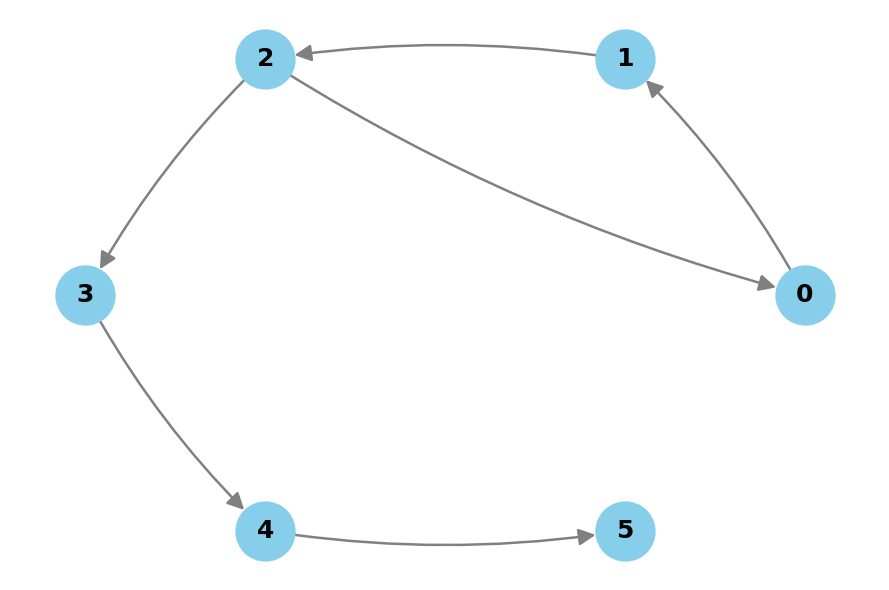

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

print(f"1. Grafo de la Matriz de adyacencia de la Red Propuesta (6 Nodos)")

# A[i, j] = 1 significa enlace dirigido de i -> j
A_propuesta = np.array([
    [0, 1, 0, 0, 0, 0], # 0 -> 1
    [0, 0, 1, 0, 0, 0], # 1 -> 2
    [1, 0, 0, 1, 0, 0], # 2 -> 0, 2 -> 3
    [0, 0, 0, 0, 1, 0], # 3 -> 4
    [0, 0, 0, 0, 0, 1], # 4 -> 5
    [0, 0, 0, 0, 0, 0]  # 5 es sumidero
])

# 2. Crear el grafo dirigido desde la matriz
# create_using=nx.DiGraph indica que es dirigido
G = nx.from_numpy_array(A_propuesta, create_using=nx.DiGraph)

# 3. Disposición espacial de los nodos
# Usamos un layout circular o spring fijando la semilla para reproducibilidad
pos = nx.circular_layout(G)

# 4. Configuración del lienzo
plt.figure(figsize=(9, 6), facecolor='white')

# Dibujar nodos con el color celeste característico
nx.draw_networkx_nodes(
    G,
    pos,
    node_color='#87CEEB',
    node_size=1800,
    alpha=1.0
)

# Dibujar las etiquetas de los nodos (0 a 5)
nx.draw_networkx_labels(
    G,
    pos,
    font_size=18,
    font_family='sans-serif',
    font_weight='bold',
    font_color='black'
)

# Dibujar las aristas con flechas grises
nx.draw_networkx_edges(
    G,
    pos,
    edge_color='gray',
    width=1.8,
    arrows=True,
    arrowsize=25,
    arrowstyle='-|>',
    node_size=1800,          # Para que la punta de la flecha no toque el centro del nodo
    connectionstyle='arc3,rad=0.08'  # Ligera curvatura para distinguir aristas
)

# Quitar ejes y márgenes innecesarios
plt.axis('off')
plt.tight_layout()
plt.show()